# Modelagem — Stroke Prediction Dataset

Este notebook corresponde às etapas de preparação, modelagem e avaliação do projeto.

A base utilizada é a versão processada gerada na EDA, com:

- remoção da coluna `id`;
- remoção do único registro com `gender = Other`;
- manutenção de `bmi` ausente para tratamento dentro do `Pipeline`.

Objetivo:

- comparar modelos de classificação;
- usar validação cruzada;
- evitar data leakage;
- registrar os experimentos no MLflow.

## 1. Carregamento das bibliotecas e da base processada

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    recall_score,
    roc_auc_score
)

import mlflow
import mlflow.sklearn

sns.set_theme(style="whitegrid")

In [2]:
DATA_PATH = Path("../data/processed/stroke_limpo.csv")

df = pd.read_csv(DATA_PATH)

print("Base carregada com sucesso.")
print("Formato:", df.shape)

display(df.head())
display(df.isnull().sum().sort_values(ascending=False))

Base carregada com sucesso.
Formato: (5109, 11)


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


bmi                  201
age                    0
gender                 0
hypertension           0
heart_disease          0
work_type              0
ever_married           0
Residence_type         0
avg_glucose_level      0
smoking_status         0
stroke                 0
dtype: int64

### Leitura da base carregada

- A base processada possui **5.109 registros** e **11 colunas**.
- A coluna `id` já foi removida.
- O registro com `gender = Other` já foi removido.
- `bmi` ainda possui **201 valores ausentes**.

Indicação:

- `bmi` será tratado dentro do `Pipeline`;
- a variável-alvo continua sendo `stroke`;
- a separação entre treino e teste deve manter a proporção das classes.

## 2. Separação entre variáveis preditoras e alvo

Nesta etapa, a base será dividida em:

- `X`: variáveis usadas para prever;
- `y`: variável-alvo `stroke`.

Também será feita a divisão entre treino e teste com `stratify=y`, por causa do desbalanceamento da classe positiva.

In [3]:
X = df.drop(columns=["stroke"])
y = df["stroke"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Formato de X_train:", X_train.shape)
print("Formato de X_test:", X_test.shape)
print("Formato de y_train:", y_train.shape)
print("Formato de y_test:", y_test.shape)

print("\nDistribuição do alvo no treino:")
display(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nDistribuição do alvo no teste:")
display(y_test.value_counts(normalize=True).mul(100).round(2))

Formato de X_train: (4087, 10)
Formato de X_test: (1022, 10)
Formato de y_train: (4087,)
Formato de y_test: (1022,)

Distribuição do alvo no treino:


stroke
0    95.13
1     4.87
Name: proportion, dtype: float64


Distribuição do alvo no teste:


stroke
0    95.11
1     4.89
Name: proportion, dtype: float64

### Leitura da divisão treino/teste

- O treino ficou com **4.087 registros**.
- O teste ficou com **1.022 registros**.
- A proporção da classe `1` foi mantida nos dois conjuntos.

Indicação:

- a divisão com `stratify=y` foi adequada;
- o teste será usado apenas na avaliação final;
- a validação cruzada será feita no conjunto de treino.

## 3. Definição do pré-processamento

Nesta etapa será criado o `ColumnTransformer`.

Tratamentos:

- numéricas contínuas: imputação + padronização;
- binárias: passagem direta;
- categóricas: imputação + OneHotEncoder.

Tudo fica dentro do `Pipeline` para evitar data leakage.

In [4]:
num_cols = ["age", "avg_glucose_level", "bmi"]
binary_cols = ["hypertension", "heart_disease"]
cat_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("bin", "passthrough", binary_cols),
    ("cat", cat_pipeline, cat_cols)
])

print("Colunas numéricas:", num_cols)
print("Colunas binárias:", binary_cols)
print("Colunas categóricas:", cat_cols)

Colunas numéricas: ['age', 'avg_glucose_level', 'bmi']
Colunas binárias: ['hypertension', 'heart_disease']
Colunas categóricas: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


## 4. Comparação inicial dos modelos

Nesta etapa serão comparados três modelos de classificação:

- Regressão Logística;
- Random Forest;
- Gradient Boosting.

A comparação será feita com validação cruzada estratificada em 5 folds.

Métricas usadas:

- F1-macro;
- Recall da classe positiva;
- ROC-AUC.

In [5]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(
        random_state=42
    )
}

scoring = {
    "f1_macro": "f1_macro",
    "recall": "recall",
    "roc_auc": "roc_auc"
}

results = []

for model_name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    
    results.append({
        "modelo": model_name,
        "f1_macro_mean": scores["test_f1_macro"].mean(),
        "f1_macro_std": scores["test_f1_macro"].std(),
        "recall_mean": scores["test_recall"].mean(),
        "recall_std": scores["test_recall"].std(),
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "roc_auc_std": scores["test_roc_auc"].std()
    })

results_df = pd.DataFrame(results).sort_values("f1_macro_mean", ascending=False)
display(results_df.round(4))

,modelo,f1_macro_mean,f1_macro_std,recall_mean,recall_std,roc_auc_mean,roc_auc_std
0,LogisticRegression,0.5412,0.0125,0.8191,0.0533,0.8389,0.0196
2,GradientBoosting,0.5144,0.0269,0.0301,0.0291,0.8383,0.0285
1,RandomForest,0.4873,0.0003,0.0000,0.0000,0.7900,0.0287


### Leitura da comparação inicial

- `LogisticRegression` teve o melhor F1-macro.
- Também apresentou o maior recall para a classe positiva.
- `GradientBoosting` teve ROC-AUC parecido, mas recall muito baixo.
- `RandomForest` praticamente não identificou casos de AVC.

Indicação:

- seguir com `LogisticRegression` como melhor modelo inicial;
- registrar os três modelos no MLflow;
- fazer tuning da Regressão Logística.

## 5. Avaliação inicial do melhor modelo

A Regressão Logística teve o melhor resultado inicial na validação cruzada.

Nesta etapa, o modelo será treinado no conjunto de treino e avaliado no conjunto de teste para visualizar:

- relatório de classificação;
- matriz de confusão.

Relatório de classificação - Regressão Logística inicial:
              precision    recall  f1-score   support

     Sem AVC       0.99      0.74      0.84       972
     Com AVC       0.13      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022

F1-macro: 0.5366
Recall classe 1: 0.8
ROC-AUC: 0.8393


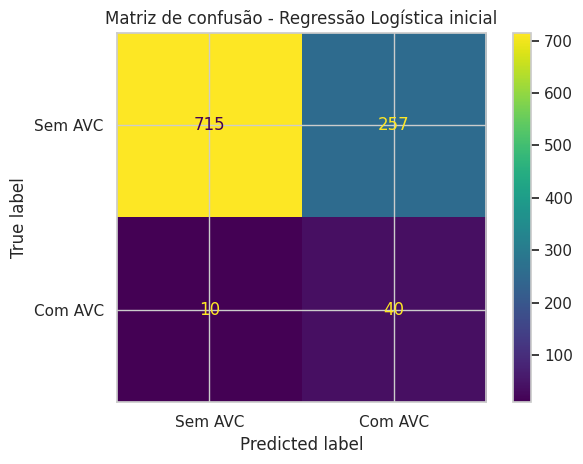

In [6]:
best_initial_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

best_initial_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_initial_model)
])

best_initial_pipe.fit(X_train, y_train)

y_pred_initial = best_initial_pipe.predict(X_test)
y_proba_initial = best_initial_pipe.predict_proba(X_test)[:, 1]

print("Relatório de classificação - Regressão Logística inicial:")
print(classification_report(y_test, y_pred_initial, target_names=["Sem AVC", "Com AVC"]))

print("F1-macro:", round(f1_score(y_test, y_pred_initial, average="macro"), 4))
print("Recall classe 1:", round(recall_score(y_test, y_pred_initial), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_initial), 4))

cm_initial = confusion_matrix(y_test, y_pred_initial)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_initial,
    display_labels=["Sem AVC", "Com AVC"]
)

disp.plot()
plt.title("Matriz de confusão - Regressão Logística inicial")
plt.tight_layout()
plt.show()

### Leitura da avaliação inicial

- O modelo acertou **40 dos 50 casos reais de AVC**.
- O recall da classe `Com AVC` foi **0,80**.
- A precisão da classe `Com AVC` foi baixa: **0,13**.
- Houve muitos falsos positivos: **257 casos**.

Indicação:

- o modelo está sensível para encontrar casos positivos;
- porém, gera muitos alertas falsos;
- esse comportamento pode fazer sentido em triagem, mas não em diagnóstico final;
- o próximo passo é registrar os experimentos no MLflow e fazer tuning.

## 6. Registro dos modelos no MLflow

Nesta etapa, os três modelos comparados serão registrados no MLflow.

Para cada modelo serão salvos:

- parâmetros principais;
- métricas da validação cruzada;
- métricas no conjunto de teste;
- matriz de confusão;
- pipeline completo com pré-processamento e modelo.

In [7]:
from pathlib import Path

mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("stroke_prediction")

screenshots_dir = Path("../screenshots")
screenshots_dir.mkdir(parents=True, exist_ok=True)

logged_runs = []

for _, row in results_df.iterrows():
    model_name = row["modelo"]
    model = models[model_name]

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    if hasattr(pipe, "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
        test_roc_auc = roc_auc_score(y_test, y_proba)
    else:
        test_roc_auc = None

    test_f1_macro = f1_score(y_test, y_pred, average="macro")
    test_recall = recall_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)
    cm_path = screenshots_dir / f"confusion_matrix_{model_name}.png"

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Sem AVC", "Com AVC"]
    )

    disp.plot()
    plt.title(f"Matriz de confusão - {model_name}")
    plt.tight_layout()
    plt.savefig(cm_path)
    plt.close()

    with mlflow.start_run(run_name=model_name) as run:
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("cv_folds", 5)
        mlflow.log_param("scoring_main", "f1_macro")
        mlflow.log_param("class_weight", str(getattr(model, "class_weight", None)))

        mlflow.log_metric("cv_f1_macro_mean", row["f1_macro_mean"])
        mlflow.log_metric("cv_f1_macro_std", row["f1_macro_std"])
        mlflow.log_metric("cv_recall_mean", row["recall_mean"])
        mlflow.log_metric("cv_recall_std", row["recall_std"])
        mlflow.log_metric("cv_roc_auc_mean", row["roc_auc_mean"])
        mlflow.log_metric("cv_roc_auc_std", row["roc_auc_std"])

        mlflow.log_metric("test_f1_macro", test_f1_macro)
        mlflow.log_metric("test_recall", test_recall)

        if test_roc_auc is not None:
            mlflow.log_metric("test_roc_auc", test_roc_auc)

        mlflow.log_artifact(str(cm_path))

        mlflow.sklearn.log_model(
            sk_model=pipe,
            artifact_path="model"
        )

        logged_runs.append({
            "modelo": model_name,
            "run_id": run.info.run_id,
            "artifact_uri": run.info.artifact_uri,
            "test_f1_macro": test_f1_macro,
            "test_recall": test_recall,
            "test_roc_auc": test_roc_auc
        })

logged_runs_df = pd.DataFrame(logged_runs)
display(logged_runs_df)

/home/lguzs/.ml/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/29 13:05:31 INFO mlflow.tracking.fluent: Experiment with name 'stroke_prediction' does not exist. Creating a new experiment.
2026/05/29 13:05:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/29 13:05:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 's

,modelo,run_id,artifact_uri,test_f1_macro,test_recall,test_roc_auc
0,LogisticRegression,f21b581b7cd1429eb3113d12978da462,file:///home/lguzs/Documents/Desafio01/noteboo...,0.536606,0.8,0.839300
1,GradientBoosting,a1845bf805cc405986d7ff1fc3fa14e1,file:///home/lguzs/Documents/Desafio01/noteboo...,0.486174,0.0,0.809105
2,RandomForest,9ff1b43bc8d74a0f90ab9a5743452bd3,file:///home/lguzs/Documents/Desafio01/noteboo...,0.487205,0.0,0.783158


### Leitura do registro no MLflow

- Os três modelos foram registrados no MLflow.
- `LogisticRegression` manteve o melhor F1-macro no teste.
- `LogisticRegression` também teve melhor recall para a classe `Com AVC`.
- `GradientBoosting` e `RandomForest` tiveram recall zero no teste.

Indicação:

- seguir com `LogisticRegression` para o tuning;
- manter os outros modelos registrados para comparação no MLflow.

## 7. Tuning do melhor modelo

O melhor modelo inicial foi a Regressão Logística.

Nesta etapa será feito ajuste de hiperparâmetros com validação cruzada estratificada.

Métrica principal:

- F1-macro.

In [8]:
from sklearn.model_selection import GridSearchCV

logreg_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"]
}

grid_search = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Melhores hiperparâmetros:")
display(grid_search.best_params_)

print("Melhor F1-macro na validação cruzada:")
display(round(grid_search.best_score_, 4))

Fitting 5 folds for each of 8 candidates, totalling 40 fits


/home/lguzs/.ml/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/lguzs/.ml/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/lguzs/.ml/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  wa

Melhores hiperparâmetros:


/home/lguzs/.ml/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


{'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

Melhor F1-macro na validação cruzada:


np.float64(0.5422)

### Leitura do tuning

- Melhor modelo: Regressão Logística.
- Melhor configuração:
  - `C = 10`
  - `penalty = l2`
  - `solver = liblinear`
- F1-macro médio na validação cruzada: **0,5422**.

Indicação:

- o tuning melhorou pouco em relação ao modelo inicial;
- mesmo assim, essa será a versão final avaliada no teste;
- o próximo passo é avaliar o modelo ajustado no conjunto de teste.

## 8. Avaliação final no conjunto de teste

Nesta etapa, o melhor modelo encontrado no tuning será avaliado no conjunto de teste.

Serão analisados:

- relatório de classificação;
- F1-macro;
- recall da classe `Com AVC`;
- ROC-AUC;
- matriz de confusão.

Relatório de classificação - Modelo final:
              precision    recall  f1-score   support

     Sem AVC       0.99      0.74      0.84       972
     Com AVC       0.13      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022

F1-macro: 0.5366
Recall classe 1: 0.8
ROC-AUC: 0.8395


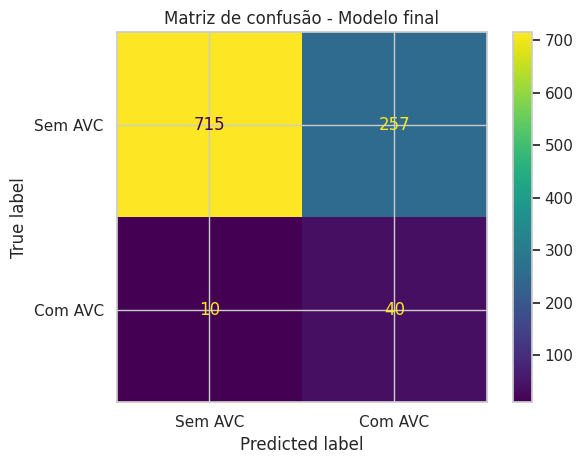

In [9]:
best_model = grid_search.best_estimator_

y_pred_final = best_model.predict(X_test)
y_proba_final = best_model.predict_proba(X_test)[:, 1]

final_f1_macro = f1_score(y_test, y_pred_final, average="macro")
final_recall = recall_score(y_test, y_pred_final)
final_roc_auc = roc_auc_score(y_test, y_proba_final)

print("Relatório de classificação - Modelo final:")
print(classification_report(y_test, y_pred_final, target_names=["Sem AVC", "Com AVC"]))

print("F1-macro:", round(final_f1_macro, 4))
print("Recall classe 1:", round(final_recall, 4))
print("ROC-AUC:", round(final_roc_auc, 4))

cm_final = confusion_matrix(y_test, y_pred_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["Sem AVC", "Com AVC"]
)

disp.plot()
plt.title("Matriz de confusão - Modelo final")
plt.tight_layout()
plt.show()

### Leitura da avaliação final

- O modelo final acertou **40 dos 50 casos reais de AVC**.
- O recall da classe `Com AVC` foi **0,80**.
- A precisão da classe `Com AVC` foi baixa: **0,13**.
- Houve **257 falsos positivos**.
- O F1-macro final foi **0,5366**.
- O ROC-AUC final foi **0,8395**.

Indicação:

- o modelo prioriza identificar casos positivos;
- há muitos falsos positivos;
- o modelo pode ser interpretado como apoio inicial de triagem;
- não deve ser usado como diagnóstico médico.

## 9. Registro do modelo final no MLflow

Nesta etapa, o modelo final ajustado será registrado no MLflow.

Serão salvos:

- melhores hiperparâmetros;
- métricas finais;
- matriz de confusão final;
- pipeline completo.

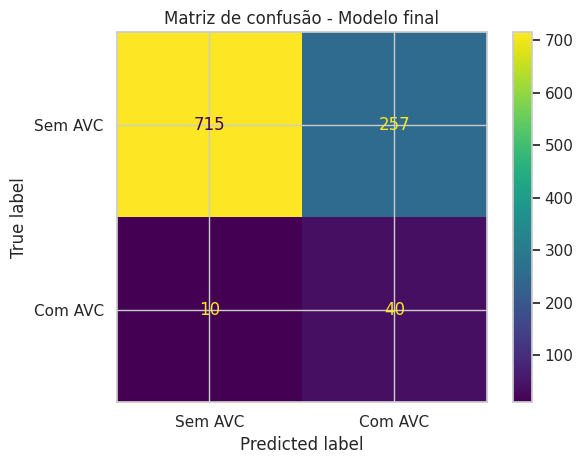

2026/05/29 13:19:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/29 13:19:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run final registrado no MLflow.
Run ID: 3c27e1c5fccb4339aab126247a59a058
Artifact URI: file:///home/lguzs/Documents/Desafio01/notebooks/../mlruns/406037047475496498/3c27e1c5fccb4339aab126247a59a058/artifacts


In [10]:
final_cm_path = screenshots_dir / "confusion_matrix_modelo_final.png"

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["Sem AVC", "Com AVC"]
)

disp.plot()
plt.title("Matriz de confusão - Modelo final")
plt.tight_layout()
plt.savefig(final_cm_path)
plt.show()

with mlflow.start_run(run_name="LogisticRegression_Tuned_Final") as final_run:
    mlflow.log_param("model_name", "LogisticRegression_Tuned_Final")
    mlflow.log_param("cv_folds", 5)
    mlflow.log_param("scoring_main", "f1_macro")
    
    for param_name, param_value in grid_search.best_params_.items():
        mlflow.log_param(param_name, param_value)

    mlflow.log_metric("best_cv_f1_macro", grid_search.best_score_)
    mlflow.log_metric("test_f1_macro", final_f1_macro)
    mlflow.log_metric("test_recall", final_recall)
    mlflow.log_metric("test_roc_auc", final_roc_auc)

    mlflow.log_artifact(str(final_cm_path))

    mlflow.sklearn.log_model(
        sk_model=best_model,
        artifact_path="model"
    )

    final_run_id = final_run.info.run_id
    final_artifact_uri = final_run.info.artifact_uri

print("Run final registrado no MLflow.")
print("Run ID:", final_run_id)
print("Artifact URI:", final_artifact_uri)

### Leitura do registro final

- O modelo final foi registrado no MLflow.
- O pipeline salvo inclui pré-processamento e Regressão Logística ajustada.
- A matriz de confusão final foi salva como artefato.
- O `Run ID` final será usado para registrar o modelo no Model Registry.

Indicação:

- promover este modelo para o Registry;
- atribuir o alias `production`;
- usar esse alias depois na API FastAPI.

## 10. Registro no Model Registry

Nesta etapa, o modelo final será registrado no MLflow Model Registry.

Nome do modelo:

`previsor_avc_stroke`

Depois do registro, será atribuído o alias:

`production`

Esse alias será usado pela API para carregar sempre a versão promovida do modelo.

In [ ]:
from mlflow.tracking import MlflowClient

model_name = "previsor_avc_stroke"

client = MlflowClient()

with mlflow.start_run(run_name="LogisticRegression_Tuned_Final_Registry") as run:
    mlflow.log_param("model_name", "LogisticRegression_Tuned_Final")
    mlflow.log_param("cv_folds", 5)
    mlflow.log_param("scoring_main", "f1_macro")

    for param_name, param_value in grid_search.best_params_.items():
        mlflow.log_param(param_name, param_value)

    mlflow.log_metric("best_cv_f1_macro", grid_search.best_score_)
    mlflow.log_metric("test_f1_macro", final_f1_macro)
    mlflow.log_metric("test_recall", final_recall)
    mlflow.log_metric("test_roc_auc", final_roc_auc)

    mlflow.log_artifact(str(final_cm_path))

    model_info = mlflow.sklearn.log_model(
        sk_model=best_model,
        name="model",
        registered_model_name=model_name
    )

    registry_run_id = run.info.run_id

# Busca a versão mais recente registrada
versions = client.search_model_versions(f"name='{model_name}'")
latest_version = max(versions, key=lambda v: int(v.version))

# Define o alias production para a versão mais recente
client.set_registered_model_alias(
    name=model_name,
    alias="production",
    version=latest_version.version
)

print("Modelo registrado e promovido para produção.")
print("Run ID:", registry_run_id)
print("Modelo:", model_name)
print("Versão em production:", latest_version.version)
print("URI para uso na API:", f"models:/{model_name}@production")
print("Model URI salvo:", model_info.model_uri)

2026/05/29 13:24:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Nova versão registrada corretamente.
Run ID: dc704d9b20f04266bedefdd9961ca3ec
Modelo: previsor_avc_stroke
Versão em production: 3
URI: models:/previsor_avc_stroke@production
Model URI salvo: models:/m-3eac583e31144b8cbe34ca3720d4b05f


Registered model 'previsor_avc_stroke' already exists. Creating a new version of this model...
Created version '3' of model 'previsor_avc_stroke'.


### Leitura do Model Registry

- O modelo `previsor_avc_stroke` foi registrado no MLflow Model Registry.
- O alias `production` foi atribuído à versão mais recente do modelo.
- A URI final para carregamento é:

`models:/previsor_avc_stroke@production`

Indicação:

- a API FastAPI deve carregar o modelo usando essa URI;
- isso evita depender diretamente de um `run_id`;
- o teste de carregamento confirmou que o modelo em produção pode ser usado.

## 11. Teste de carregamento do modelo em produção

Nesta etapa será testado o carregamento do modelo usando a mesma URI que será usada na API.

Objetivo:

- verificar se o alias `production` funciona;
- simular uma predição com um registro do conjunto de teste.

In [16]:
model_uri = "models:/previsor_avc_stroke@production"

loaded_model = mlflow.pyfunc.load_model(model_uri)

sample = X_test.head(1)
prediction = loaded_model.predict(sample)

print("Modelo carregado com sucesso.")
print("URI:", model_uri)

print("\nEntrada usada no teste:")
display(sample)

print("\nPredição:")
display(prediction)

Modelo carregado com sucesso.
URI: models:/previsor_avc_stroke@production

Entrada usada no teste:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
3666,Female,28.0,1,0,Yes,Govt_job,Rural,83.66,36.4,never smoked



Predição:


array([0])

In [4]:
from sklearn.model_selection import RandomizedSearchCV

# Testar diferentes configurações da Regressão Logística
# C controla a regularização: valores menores = modelo mais simples
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["lbfgs", "liblinear"],
    "model__penalty": ["l2"]
}

pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42
    ))
])

search = RandomizedSearchCV(
    pipe_lr,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Melhores parâmetros:", search.best_params_)
print("Melhor F1-macro:", search.best_score_.round(4))

/home/lguzs/.ml/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/lguzs/.ml/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/lguzs/.ml/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'pen

Melhores parâmetros: {'model__solver': 'liblinear', 'model__penalty': 'l2', 'model__C': 0.1}
Melhor F1-macro: 0.5387


/home/lguzs/.ml/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


              precision    recall  f1-score   support

     Sem AVC       0.99      0.73      0.84       972
     Com AVC       0.13      0.80      0.23        50

    accuracy                           0.73      1022
   macro avg       0.56      0.76      0.53      1022
weighted avg       0.94      0.73      0.81      1022



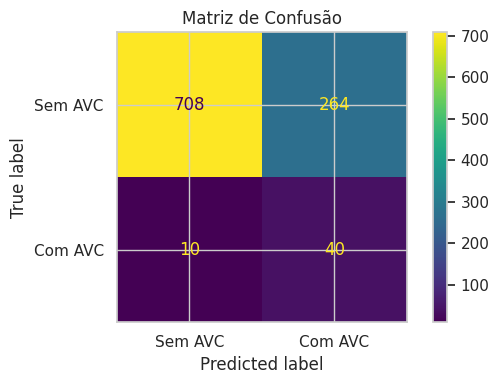

In [5]:
# Treinar o modelo final com os melhores parâmetros encontrados
modelo_final = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        C=0.1,
        solver="liblinear",
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

modelo_final.fit(X_train, y_train)
y_pred = modelo_final.predict(X_test)

# Métricas no conjunto de teste
print(classification_report(y_test, y_pred, target_names=["Sem AVC", "Com AVC"]))

# Matriz de confusão
# Mostra quantos acertos e erros o modelo cometeu em cada classe
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Sem AVC", "Com AVC"],
    ax=ax
)
plt.title("Matriz de Confusão")
plt.tight_layout()
plt.savefig("../screenshots/confusion_matrix.png")
plt.show()